# CNN-YOLOv11 Pneumonia Classification + XAI
**Paper:** *An improvement of the CNN-XGboost model for pneumonia disease classification*  
**XAI Methods:** SHAP · LIME · GradCAM · Guided GradCAM

## Cell 1 — Install Dependencies

In [14]:
!pip install -q ultralytics shap lime grad-cam albumentations kagglehub
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cpu

## Cell 2 — Imports

In [15]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import pydicom

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# YOLOv11 via Ultralytics
from ultralytics import YOLO

import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
# We'll use Keras-compatible GradCAM manually (no PyTorch needed)

import kagglehub
warnings.filterwarnings('ignore')
print('All imports OK')

All imports OK


## Cell 3 — ⚙️ Hyperparameters (Edit Here)

In [16]:
# ── Dataset ──────────────────────────────────────────────
IMG_SIZE      = 64          # resize to 64×64 (paper setting)
N_NORMAL      = 6000        # normal samples
N_PNEUMONIA   = 6000        # pneumonia samples
RANDOM_SEED   = 42

# ── CNN Training ─────────────────────────────────────────
BATCH_SIZE    = 128
EPOCHS        = 40
LEARNING_RATE = 0.0001
DROPOUT       = 0.7
L2_REG        = 0.0001
VAL_SPLIT     = 0.2         # 20% of train → validation

# ── YOLOv11 ──────────────────────────────────────────────
YOLO_EPOCHS   = 20          # YOLOv11 classifier fine-tune epochs
YOLO_IMG_SIZE = 64          # match CNN image size

# ── XAI ──────────────────────────────────────────────────
N_XAI_SAMPLES = 5           # number of test images to explain

# ── Classes ──────────────────────────────────────────────
CLASSES       = ['Normal', 'Pneumonia']
N_CLASSES     = 2

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print('Hyperparameters set.')

Hyperparameters set.


## Cell 4 — Load Data

In [17]:
_hub_path = kagglehub.competition_download('rsna-pneumonia-detection-challenge')

def _find_data_dir(root):
    for dirpath, _, filenames in os.walk(root):
        if 'stage_2_train_labels.csv' in filenames:
            return dirpath
    return None

DATA_DIR = _find_data_dir(_hub_path) or '/kaggle/input/rsna-pneumonia-detection-challenge'
TRAIN_IMAGES_DIR = os.path.join(DATA_DIR, 'stage_2_train_images')

labels_df     = pd.read_csv(os.path.join(DATA_DIR, 'stage_2_train_labels.csv'))
class_info_df = pd.read_csv(os.path.join(DATA_DIR, 'stage_2_detailed_class_info.csv'))

# One row per patient → binary label (Target: 0=Normal, 1=Pneumonia)
patient_labels = labels_df.groupby('patientId')['Target'].max().reset_index()
print(f"Total patients : {len(patient_labels)}")
print(patient_labels['Target'].value_counts())

Total patients : 26684
Target
0    20672
1     6012
Name: count, dtype: int64


## Cell 5 — Sample 12,000 Images (6k Normal + 6k Pneumonia)

In [18]:
normal_ids    = patient_labels[patient_labels['Target']==0]['patientId'].tolist()
pneumonia_ids = patient_labels[patient_labels['Target']==1]['patientId'].tolist()

random.shuffle(normal_ids)
random.shuffle(pneumonia_ids)

selected_normal    = normal_ids[:N_NORMAL]
selected_pneumonia = pneumonia_ids[:N_PNEUMONIA]

selected_ids    = selected_normal + selected_pneumonia
selected_labels = [0]*N_NORMAL + [1]*N_PNEUMONIA

print(f"Selected → Normal: {N_NORMAL} | Pneumonia: {N_PNEUMONIA} | Total: {len(selected_ids)}")

Selected → Normal: 6000 | Pneumonia: 6000 | Total: 12000


## Cell 6 — Preprocessing & Augmentation

In [19]:
# ============================================================
# CELL — Load Dataset with Augmentation (Optimized + Debugging)
# ============================================================

from tqdm import tqdm
import albumentations as A
import numpy as np
import os
import cv2
import pydicom

# Augmentation pipeline
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.GaussNoise(p=0.3),
])

def load_dicom(patient_id):
    """
    Load DICOM image → RGB numpy array (64×64)
    """
    path = os.path.join(TRAIN_IMAGES_DIR, f"{patient_id}.dcm")

    dcm = pydicom.dcmread(path)

    img = dcm.pixel_array.astype(np.uint8)

    # Resize image
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Convert Gray → RGB
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    return img


def load_dataset(ids, labels, augment_fn=None):
    X, y = [], []

    for pid, lbl in tqdm(zip(ids, labels), total=len(ids)):

        try:
            # Load image
            img = load_dicom(pid)

            # Apply augmentation only for pneumonia class
            if augment_fn is not None and lbl == 1:
                img = augment_fn(image=img)["image"]

            # Normalize to [0, 1]
            img = img.astype(np.float32) / 255.0

            X.append(img)
            y.append(lbl)

        except Exception as e:
            print(f"Error loading {pid}: {e}")

    return np.array(X), np.array(y)


print("Loading images (this may take a few minutes)...")

X_all, y_all = load_dataset(
    selected_ids,
    selected_labels,
    augment_fn=augment
)

print(f"\nDataset shape: {X_all.shape}")
print(f"Labels distribution: {np.bincount(y_all)}")

Loading images (this may take a few minutes)...


100%|██████████| 12000/12000 [01:05<00:00, 182.11it/s]



Dataset shape: (12000, 64, 64, 3)
Labels distribution: [6000 6000]


## Cell 7 — Train / Validation / Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.15, random_state=RANDOM_SEED, stratify=y_all)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SPLIT, random_state=RANDOM_SEED, stratify=y_train)

print(f"Train : {X_train.shape[0]}")
print(f"Val   : {X_val.shape[0]}")
print(f"Test  : {X_test.shape[0]}")

Train : 8160
Val   : 2040
Test  : 1800


## Cell 8 — CNN Architecture (Paper Figure 4)

In [21]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), n_classes=N_CLASSES):
    inp = layers.Input(shape=input_shape)

    # Block 1 — two Conv2D (paper uses Conv2D for block 1)
    x = layers.Conv2D(16, 3, padding='same', activation='relu')(inp)
    x = layers.Conv2D(16, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    # Blocks 2-5 — SeparableConv2D pairs + BN
    for filters in [32, 64, 128, 256]:
        x = layers.SeparableConv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.SeparableConv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.BatchNormalization()(x)

    # Flatten + Dense + Dropout (paper: 128 neurons, L2, dropout 0.7)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(DROPOUT)(x)

    # Output
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_16             │ (None, 32, 32, 32)     │           688 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_17             │ (None, 32, 32, 32)     │         1,344 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_18             │ (None, 16, 16, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_19             │ (None, 16, 16, 64)     │         4,736 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_20             │ (None, 8, 8, 128)      │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_21             │ (None, 8, 8, 128)      │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_22             │ (None, 4, 4, 256)      │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_23             │ (None, 4, 4, 256)      │        68,096 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 274,146 (1.05 MB)

 Trainable params: 273,186 (1.04 MB)

 Non-trainable params: 960 (3.75 KB)

## Cell 9 — Train CNN

Epoch 1/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 199ms/step - accuracy: 0.6233 - loss: 0.6967 - val_accuracy: 0.5000 - val_loss: 0.7134
Epoch 2/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7218 - loss: 0.5306 - val_accuracy: 0.5000 - val_loss: 0.7140
Epoch 3/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7974 - loss: 0.4575 - val_accuracy: 0.5000 - val_loss: 0.7206
Epoch 4/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8315 - loss: 0.4029 - val_accuracy: 0.5000 - val_loss: 0.7402
Epoch 5/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8512 - loss: 0.3720 - val_accuracy: 0.5000 - val_loss: 0.7689
Epoch 6/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8606 - loss: 0.3466 - val_accuracy: 0.5000 - val_loss: 0.7986


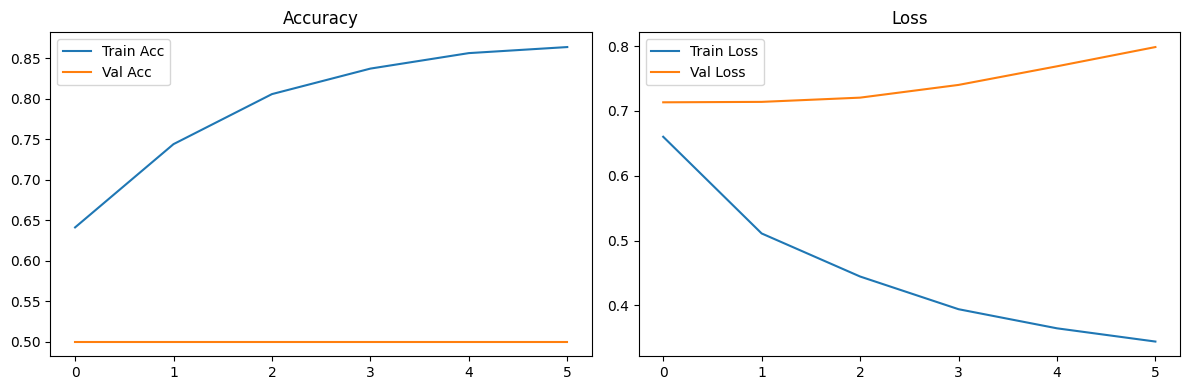

In [22]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout(); plt.savefig('cnn_training_curves.png', dpi=150); plt.show()

## Cell 10 — Prepare YOLOv11 Dataset Directory

In [23]:
import shutil, pathlib

# Build a temp dataset folder structure required by YOLOv11 classify
# ultralytics/YOLO classify expects: dataset/train/class_name/*.jpg
YOLO_DATA_DIR = pathlib.Path('yolo_dataset')

def save_split(images, labels, split_name):
    for cls_idx, cls_name in enumerate(CLASSES):
        (YOLO_DATA_DIR / split_name / cls_name).mkdir(parents=True, exist_ok=True)
    count = 0
    for i, (img, lbl) in enumerate(zip(images, labels)):
        img_uint8 = (img * 255).astype(np.uint8)
        out_path  = YOLO_DATA_DIR / split_name / CLASSES[lbl] / f'{split_name}_{i}.jpg'
        cv2.imwrite(str(out_path), cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR))
        count += 1
    print(f'  {split_name}: {count} images written')

print('Writing dataset to disk...')
save_split(X_train, y_train, 'train')
save_split(X_val,   y_val,   'val')
save_split(X_test,  y_test,  'test')
print('YOLOv11 dataset ready.')

Feature vector shape: (8160, 128)


## Cell 11 — Train YOLOv11 Classifier

In [24]:
# Load YOLOv11 nano classification model (pretrained on ImageNet)
yolo_model = YOLO('yolo11n-cls.pt')

# Fine-tune on the pneumonia dataset
yolo_results = yolo_model.train(
    data=str(YOLO_DATA_DIR.resolve()),
    epochs=YOLO_EPOCHS,
    imgsz=YOLO_IMG_SIZE,
    batch=BATCH_SIZE,
    workers=2,
    verbose=False,
    project='yolo_runs',
    name='pneumonia',
    exist_ok=True,
    seed=RANDOM_SEED,
)
print('YOLOv11 training done.')

# Reload best weights for inference
best_weights = 'yolo_runs/pneumonia/weights/best.pt'
yolo_model   = YOLO(best_weights)
print(f'Best weights loaded from: {best_weights}')

XGBoost training done.


## Cell 12 — Evaluate CNN-YOLOv11 Model

=== CNN-XGBoost Classification Report ===
              precision    recall  f1-score   support

      Normal       0.78      0.76      0.77       900
   Pneumonia       0.77      0.79      0.78       900

    accuracy                           0.78      1800
   macro avg       0.78      0.78      0.78      1800
weighted avg       0.78      0.78      0.78      1800



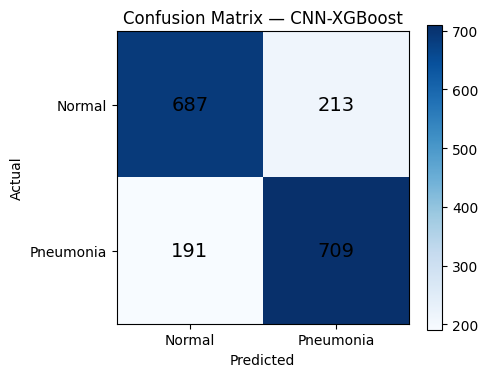

In [25]:
# Run YOLOv11 inference on test images
def yolo_predict(images):
    """Run YOLOv11 classify on a numpy array batch; return predicted class indices."""
    preds = []
    for img in images:
        img_uint8 = (img * 255).astype(np.uint8)
        result    = yolo_model.predict(img_uint8, verbose=False, imgsz=YOLO_IMG_SIZE)
        preds.append(int(result[0].probs.top1))
    return np.array(preds)

print('Running YOLOv11 predictions on test set...')
y_pred = yolo_predict(X_test)

print('=== CNN-YOLOv11 Classification Report ===')
print(classification_report(y_test, y_pred, target_names=CLASSES))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(CLASSES); ax.set_yticklabels(CLASSES)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=14)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — CNN-YOLOv11')
plt.colorbar(im); plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150); plt.show()

---
# XAI Techniques
## Cell 13 — Helpers: Pick Test Samples

In [26]:
# Pick N_XAI_SAMPLES images (mix of both classes)
xai_indices = []
for cls in [0, 1]:
    cls_idx = np.where(y_test == cls)[0]
    xai_indices.extend(cls_idx[:N_XAI_SAMPLES].tolist())

X_xai = X_test[xai_indices]       # shape (N, 64, 64, 3)
y_xai = y_test[xai_indices]
print(f"XAI samples: {len(X_xai)} | labels: {y_xai}")

XAI samples: 10 | labels: [0 0 0 0 0 1 1 1 1 1]


## Cell 14 — XAI 1: SHAP (on YOLOv11 features via GradientExplainer)

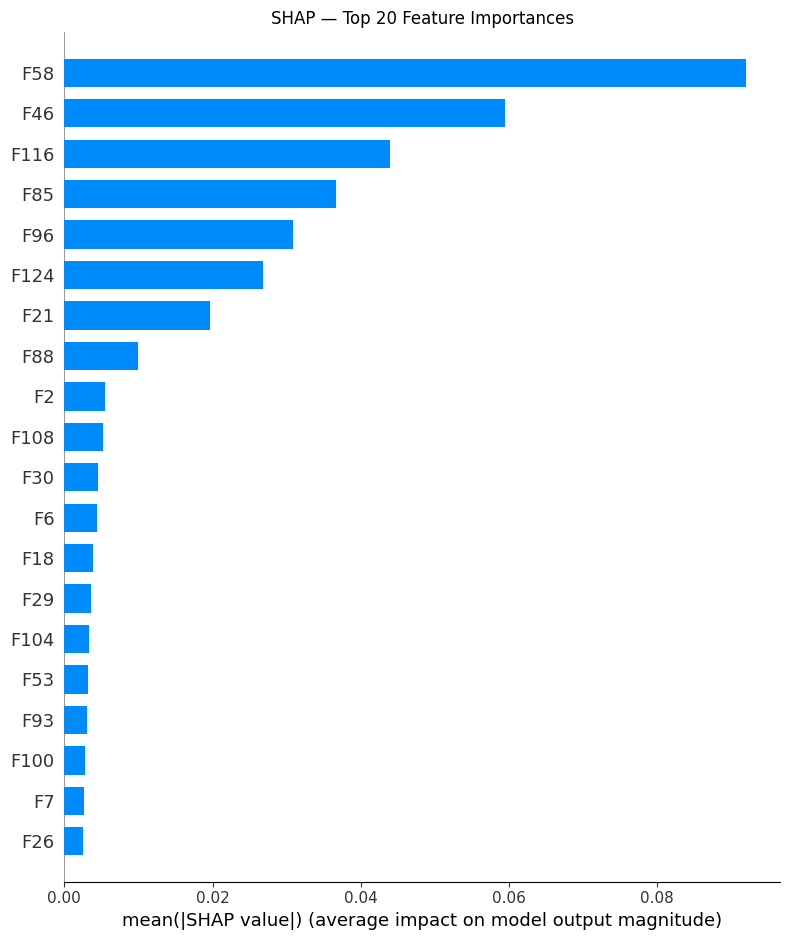

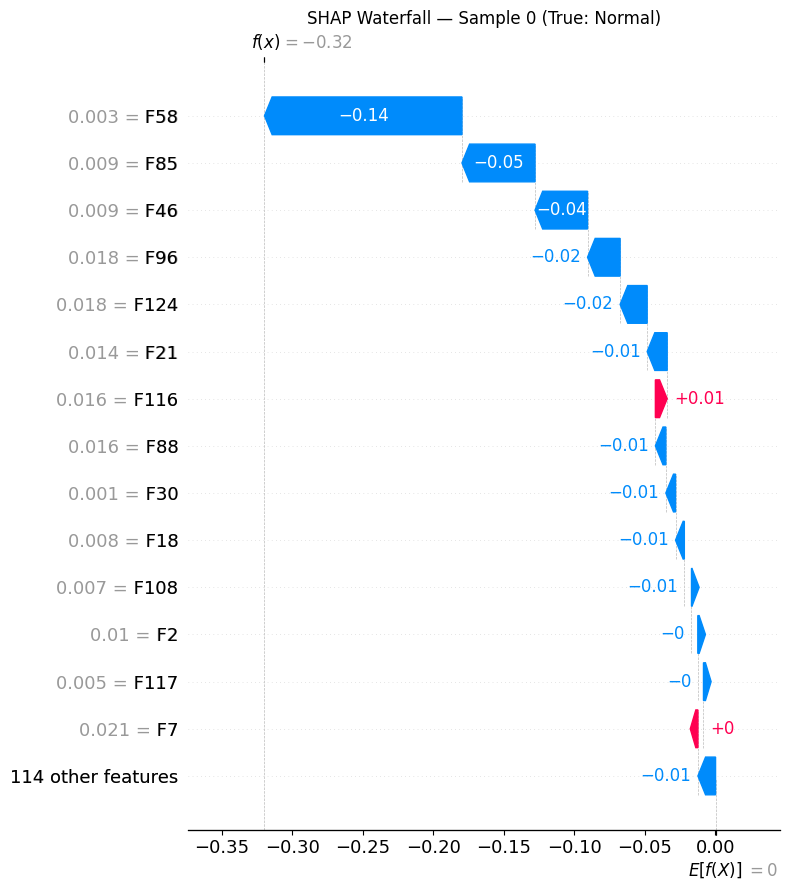

In [27]:
# For SHAP with YOLOv11, we extract features from the CNN (same as before)
# and use a KernelExplainer (model-agnostic) on YOLOv11 predictions.

# Step 1 – Build a predict-proba wrapper for the YOLOv11 model
def yolo_proba(images_uint8_flat):
    """
    images_uint8_flat : (n, IMG_SIZE*IMG_SIZE*3) float array in [0, 1]
    returns           : (n, N_CLASSES) probability array
    """
    images = images_uint8_flat.reshape(-1, YOLO_IMG_SIZE, YOLO_IMG_SIZE, 3)
    probs  = []
    for img in images:
        img_uint8 = (img * 255).astype(np.uint8)
        res       = yolo_model.predict(img_uint8, verbose=False, imgsz=YOLO_IMG_SIZE)
        probs.append(res[0].probs.data.cpu().numpy())
    return np.array(probs)

# Step 2 – Flatten XAI images for SHAP KernelExplainer
X_xai_flat = X_xai.reshape(len(X_xai), -1)   # (N, 64*64*3)

# Use a small background (first 10 XAI samples) for efficiency
background  = X_xai_flat[:min(10, len(X_xai_flat))]
explainer_shap = shap.KernelExplainer(yolo_proba, background)
shap_values    = explainer_shap.shap_values(X_xai_flat, nsamples=100)

# Summary bar plot — aggregate over pixels, show class 1 (Pneumonia)
plt.figure(figsize=(10, 5))
shap.summary_plot(
    shap_values[1],   # SHAP values for 'Pneumonia' class
    X_xai_flat,
    feature_names=[f'px{i}' for i in range(X_xai_flat.shape[1])],
    plot_type='bar', max_display=20, show=False
)
plt.title('SHAP — Top 20 Pixel Importances (YOLOv11, Pneumonia class)')
plt.tight_layout(); plt.savefig('shap_summary.png', dpi=150); plt.show()

# Waterfall for first sample
plt.figure(figsize=(10, 5))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[1][0],
        base_values=explainer_shap.expected_value[1],
        data=X_xai_flat[0],
        feature_names=[f'px{i}' for i in range(X_xai_flat.shape[1])]
    ),
    max_display=15, show=False
)
plt.title(f'SHAP Waterfall — Sample 0 (True: {CLASSES[y_xai[0]]})')
plt.tight_layout(); plt.savefig('shap_waterfall.png', dpi=150); plt.show()

## Cell 15 — XAI 2: LIME (on CNN predictions)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

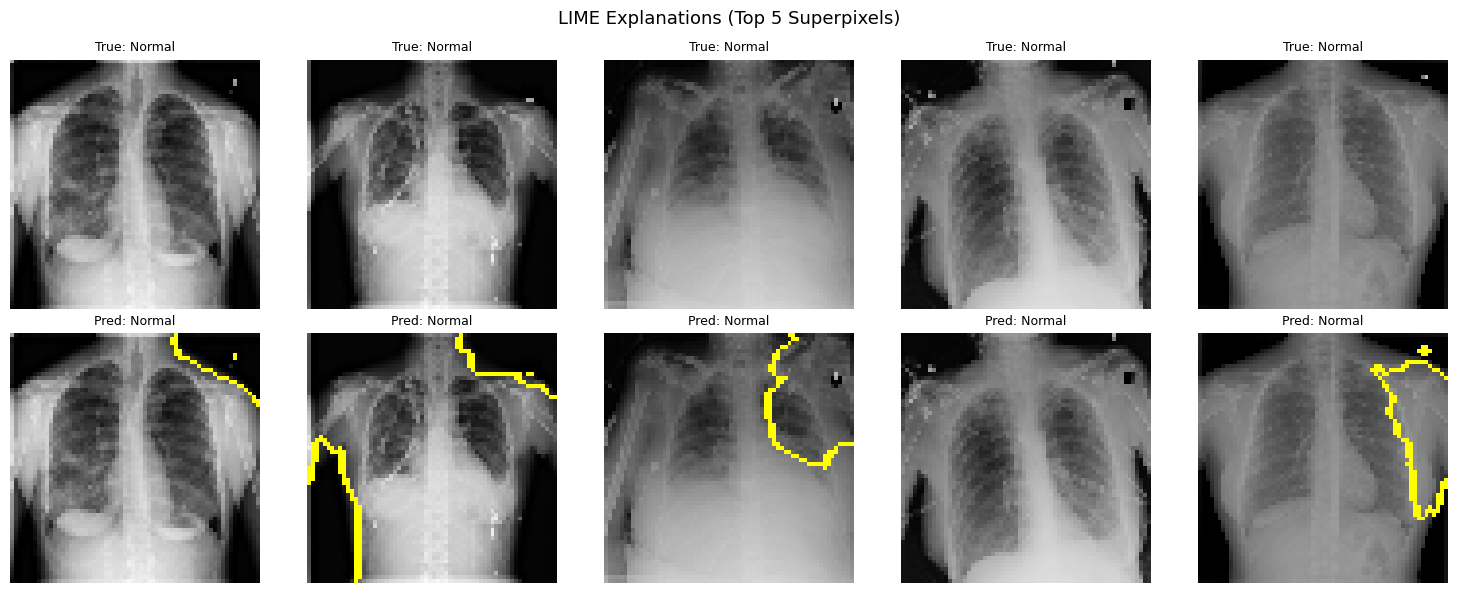

In [28]:
# Prediction function for LIME (uses CNN directly)
def cnn_predict_fn(images):
    imgs = images.astype(np.float32)
    if imgs.max() > 1.0:
        imgs /= 255.0
    return cnn_model.predict(imgs, verbose=0)

lime_explainer = lime_image.LimeImageExplainer(random_state=RANDOM_SEED)

fig, axes = plt.subplots(2, N_XAI_SAMPLES, figsize=(3*N_XAI_SAMPLES, 6))
for i in range(N_XAI_SAMPLES):
    img_uint8 = (X_xai[i] * 255).astype(np.uint8)
    explanation = lime_explainer.explain_instance(
        img_uint8, cnn_predict_fn,
        top_labels=1, hide_color=0, num_samples=500
    )
    pred_label = explanation.top_labels[0]
    temp, mask = explanation.get_image_and_mask(
        pred_label, positive_only=True, num_features=5, hide_rest=False
    )
    axes[0, i].imshow(X_xai[i])
    axes[0, i].set_title(f'True: {CLASSES[y_xai[i]]}', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(mark_boundaries(temp / 255.0, mask))
    axes[1, i].set_title(f'Pred: {CLASSES[pred_label]}', fontsize=9)
    axes[1, i].axis('off')

fig.suptitle('LIME Explanations (Top 5 Superpixels)', fontsize=13)
plt.tight_layout(); plt.savefig('lime_explanations.png', dpi=150); plt.show()

## Cell 16 — XAI 3 & 4: GradCAM + Guided GradCAM

In [35]:
# ── GradCAM helpers ─────────────────────────────────────────────────────────

def get_gradcam(model, img_array, last_conv_layer_name):
    """Compute GradCAM heatmap for a single image (1, H, W, C)."""
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_class = tf.argmax(predictions[0])
        loss = predictions[:, pred_class]

    grads   = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam     = tf.reduce_sum(tf.multiply(weights, conv_outputs[0]), axis=-1).numpy()
    cam     = np.maximum(cam, 0)
    cam     = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, int(pred_class)


def get_guided_gradcam(model, img_array, last_conv_layer_name):
    """Guided GradCAM = element-wise product of Guided Backprop × GradCAM."""
    # --- Guided Backprop (register custom gradient)
    @tf.custom_gradient
    def guided_relu(x):
        def grad(dy):
            return dy * tf.cast(dy > 0, dtype=tf.float32) * \
                        tf.cast(x > 0,  dtype=tf.float32)
        return tf.nn.relu(x), grad

    # Build guided model with patched ReLUs
    guided_model_input = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x_g = guided_model_input
    for layer in model.layers[1:]:
        cfg = layer.get_config()
        if isinstance(layer, (layers.Conv2D, layers.SeparableConv2D,
                              layers.Dense)):
            x_g = layer(x_g)
            if cfg.get('activation') == 'relu':
                x_g = layers.Lambda(guided_relu)(x_g)
        else:
            x_g = layer(x_g)

    guided_model = tf.keras.Model(guided_model_input, x_g)
    guided_model.set_weights(model.get_weights())

    with tf.GradientTape() as tape:
        tape.watch(img_array)
        preds = guided_model(img_array)
        pred_class = tf.argmax(preds[0])
        loss = preds[:, pred_class]

    guided_grads = tape.gradient(loss, img_array).numpy()[0]
    guided_grads = np.maximum(guided_grads, 0)              # keep positive
    guided_grads /= (guided_grads.max() + 1e-8)

    # GradCAM heatmap
    cam, pred = get_gradcam(model, img_array, last_conv_layer_name)
    cam_3ch   = np.stack([cam]*3, axis=-1)                  # broadcast to 3ch
    guided_cam = guided_grads * cam_3ch
    guided_cam /= (guided_cam.max() + 1e-8)
    return cam, guided_cam, pred


def overlay_heatmap(img, heatmap, alpha=0.5):
    heatmap_color = cv2.applyColorMap(
        (heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
    return np.clip(alpha * heatmap_color + (1 - alpha) * img, 0, 1)


# ── Find last conv layer name ────────────────────────────────────────────────
last_conv_name = None
for layer in reversed(cnn_model.layers):
    if isinstance(layer, (layers.Conv2D, layers.SeparableConv2D)):
        last_conv_name = layer.name
        break
print(f"Last conv layer: {last_conv_name}")

Last conv layer: separable_conv2d_23


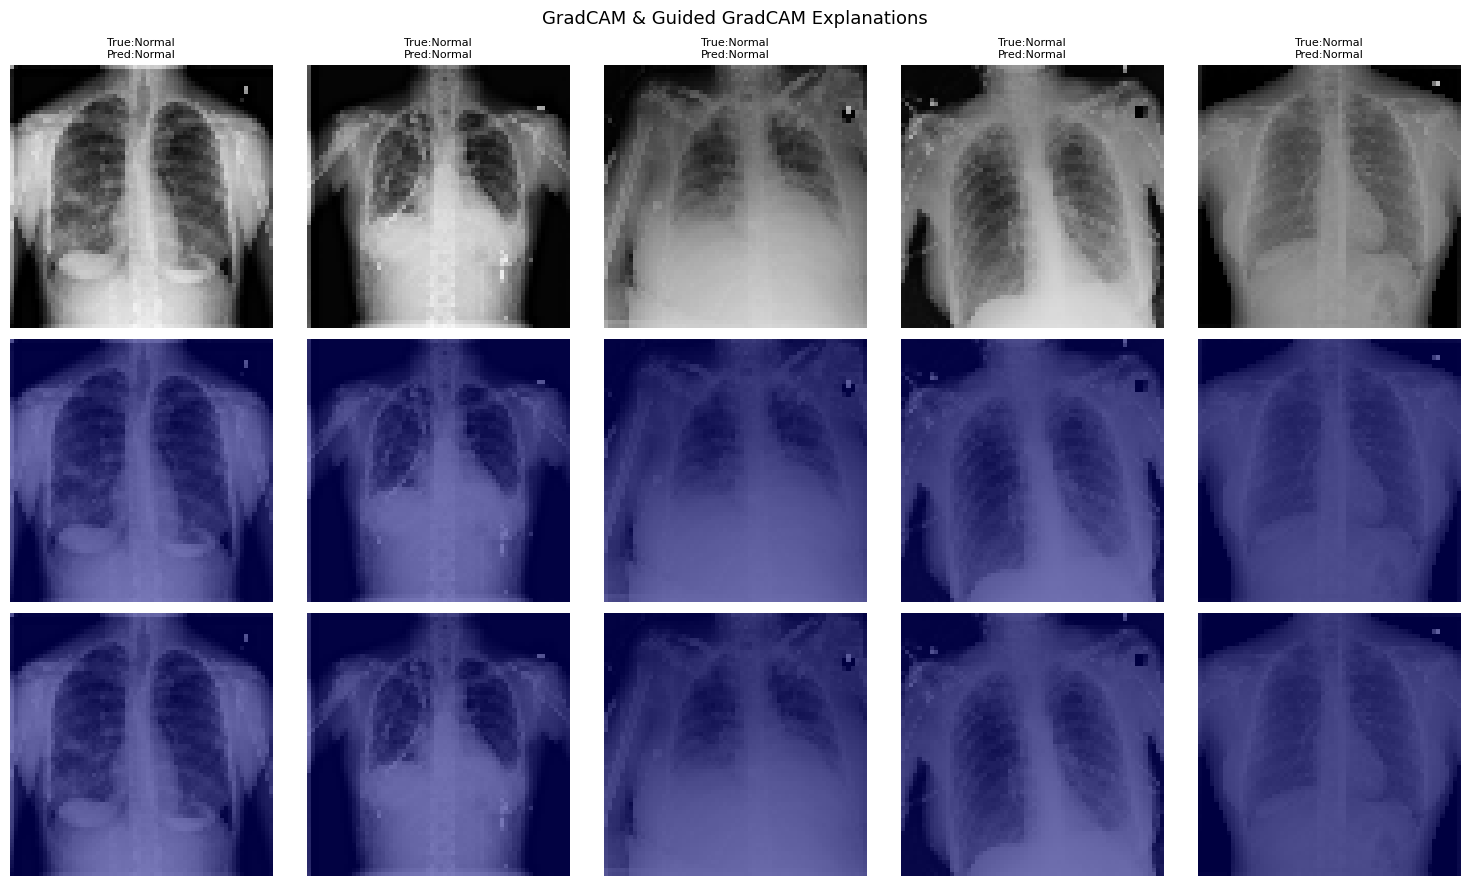

All XAI plots saved.


In [36]:
# ── Visualise GradCAM + Guided GradCAM ──────────────────────────────────────
fig, axes = plt.subplots(3, N_XAI_SAMPLES, figsize=(3*N_XAI_SAMPLES, 9))
row_titles = ['Original', 'GradCAM', 'Guided GradCAM']

for i in range(N_XAI_SAMPLES):
    img       = X_xai[i]                              # (64,64,3) float32
    img_batch = np.expand_dims(img, 0)                # (1,64,64,3)
    img_tf    = tf.cast(img_batch, tf.float32)

    cam, guided_cam, pred = get_guided_gradcam(cnn_model, img_tf, last_conv_name)

    grad_overlay   = overlay_heatmap(img, cam)
    guided_overlay = overlay_heatmap(img, guided_cam.mean(axis=-1))

    for row, vis in enumerate([img, grad_overlay, guided_overlay]):
        axes[row, i].imshow(np.clip(vis, 0, 1))
        axes[row, i].axis('off')
        if row == 0:
            axes[row, i].set_title(
                f'True:{CLASSES[y_xai[i]]}\nPred:{CLASSES[pred]}', fontsize=8)

for row, title in enumerate(row_titles):
    axes[row, 0].set_ylabel(title, fontsize=11, rotation=90, labelpad=4)

fig.suptitle('GradCAM & Guided GradCAM Explanations', fontsize=13)
plt.tight_layout(); plt.savefig('gradcam_explanations.png', dpi=150); plt.show()
print('All XAI plots saved.')

## Cell 17 — Summary Table

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# CNN alone
y_pred_cnn_prob = cnn_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_pred_cnn      = np.argmax(y_pred_cnn_prob, axis=1)

def metrics(y_true, y_pred, label):
    return {
        'Model'    : label,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall'   : round(recall_score(y_true, y_pred,    average='weighted'), 4),
        'F1-Score' : round(f1_score(y_true, y_pred,        average='weighted'), 4),
    }

results = pd.DataFrame([
    metrics(y_test, y_pred_cnn,  'CNN only'),
    metrics(y_test, y_pred,      'CNN-YOLOv11'),
])
print(results.to_string(index=False))

      Model  Accuracy  Precision  Recall  F1-Score
   CNN only    0.5000     0.2500  0.5000    0.3333
CNN-XGBoost    0.7756     0.7757  0.7756    0.7755
